Load & Inspect Data

In [5]:
import pandas as pd

# Load datasets
node1 = pd.read_csv('/content/Dataset-AAKTP-Node 1 Baby chick section.csv')
node2 = pd.read_csv('/content/Dataset-AAKTP-Node 2 Main-East-Zone.csv')
node3 = pd.read_csv('/content/Dataset-AAKTP-Node 3 Main West-Zone.csv')

# Preview
node1.head()
node1.info()
node1.describe()

node2.head()
node2.info()
node2.describe()

node3.head()
node3.info()
node3.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85984 entries, 0 to 85983
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Time         85984 non-null  object
 1   Temperature  85984 non-null  int64 
 2   Humidity     85984 non-null  int64 
 3   Noise-Avg    85984 non-null  int64 
 4   Noise-Peak   85984 non-null  int64 
 5   Light        85984 non-null  int64 
 6   H2S          85984 non-null  int64 
 7   NH3          85984 non-null  int64 
 8   NO2          85984 non-null  int64 
 9   PM2-5        85984 non-null  int64 
 10  PM10         85984 non-null  int64 
 11  TVOC         85984 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 7.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80987 entries, 0 to 80986
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Time         80987 non-null  object
 1   Temperature  80987 non-null  

,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC
count,87127.000000,87127.000000,87127.000000,87127.000000,87127.000000,87127.000000,87127.000000,87127.000000,87127.000000,87127.000000,87127.000000
mean,25.889334,68.010674,114.209591,153.188369,273.310397,0.201809,32.765733,0.289084,7.886350,8.025365,115.868938
std,5.675299,13.297413,85.107290,134.210540,316.324204,1.696589,13.044680,0.573559,29.331946,30.321956,80.860302
min,0.000000,0.000000,46.000000,47.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,58.000000,46.000000,48.000000,4.000000,0.000000,24.000000,0.000000,0.000000,0.000000,58.000000
50%,27.000000,72.000000,47.000000,50.000000,32.000000,0.000000,30.000000,0.000000,3.000000,3.000000,96.000000
75%,29.000000,77.000000,199.000000,256.000000,702.000000,0.000000,41.000000,0.000000,10.000000,10.000000,150.000000
max,38.000000,345.000000,308.000000,599.000000,717.000000,101.000000,201.000000,6.000000,4745.000000,5186.000000,500.000000


Data Cleaning & Accuracy Analysis

In [6]:
# Missing values
node1.isnull().sum()
node2.isnull().sum()
node3.isnull().sum()

# Check duplicates
node1.duplicated().sum()
node2.duplicated().sum()
node3.duplicated().sum()

# Data types
node1.dtypes
node2.dtypes
node3.dtypes

,0
Time,object
Temperature,int64
Humidity,int64
Noise-Avg,int64
Noise-Peak,int64
Light,int64
H2S,int64
NH3,int64
NO2,int64
PM2-5,int64


Anomaly Detection

In [7]:
import pandas as pd
import numpy as np

# Load datasets
node1 = pd.read_csv('/content/Dataset-AAKTP-Node 1 Baby chick section.csv')
node2 = pd.read_csv('/content/Dataset-AAKTP-Node 2 Main-East-Zone.csv')
node3 = pd.read_csv('/content/Dataset-AAKTP-Node 3 Main West-Zone.csv')

# Define Outlier Function
def detect_outliers_iqr(df, dataset_name):
    print(f"\n ➤ Outlier Summary for {dataset_name}")

    # Select numeric columns only
    numeric_cols = df.select_dtypes(include=np.number).columns

    outlier_summary = {}

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = len(outliers)

    return pd.DataFrame(list(outlier_summary.items()), columns=['Feature', 'Outlier Count'])

#Run for All Nodes
outliers_node1 = detect_outliers_iqr(node1, "Node 1 (Baby Chick Section)")
outliers_node2 = detect_outliers_iqr(node2, "Node 2 (East Zone)")
outliers_node3 = detect_outliers_iqr(node3, "Node 3 (West Zone)")

# Display results
outliers_node1.sort_values(by='Outlier Count', ascending=False)


 ➤ Outlier Summary for Node 1 (Baby Chick Section)

 ➤ Outlier Summary for Node 2 (East Zone)

 ➤ Outlier Summary for Node 3 (West Zone)


,Feature,Outlier Count
7,NO2,21094
5,H2S,18702
6,NH3,7252
9,PM10,4984
1,Humidity,4881
8,PM2-5,4818
0,Temperature,3060
10,TVOC,2541
2,Noise-Avg,0
3,Noise-Peak,0


In [8]:
outliers_node2.sort_values(by='Outlier Count', ascending=False)

,Feature,Outlier Count
7,NO2,18412
0,Temperature,15534
1,Humidity,14138
3,Noise-Peak,11869
6,NH3,5729
5,H2S,3624
9,PM10,2212
8,PM2-5,2112
2,Noise-Avg,1980
10,TVOC,1169


In [9]:
outliers_node3.sort_values(by='Outlier Count', ascending=False)

,Feature,Outlier Count
7,NO2,21096
9,PM10,4323
8,PM2-5,4111
10,TVOC,3318
5,H2S,2792
6,NH3,1660
0,Temperature,832
1,Humidity,738
3,Noise-Peak,57
2,Noise-Avg,0


Anomaly Comparison Across Nodes

In [10]:
# Merge summaries for comparison
comparison = outliers_node1.merge(outliers_node2, on='Feature', suffixes=('_Node1', '_Node2'))
comparison = comparison.merge(outliers_node3, on='Feature')
comparison.rename(columns={'Outlier Count': 'Outlier Count_Node3'}, inplace=True)

comparison

,Feature,Outlier Count_Node1,Outlier Count_Node2,Outlier Count_Node3
0,Temperature,3060,15534,832
1,Humidity,4881,14138,738
2,Noise-Avg,0,1980,0
3,Noise-Peak,0,11869,57
4,Light,0,0,0
5,H2S,18702,3624,2792
6,NH3,7252,5729,1660
7,NO2,21094,18412,21096
8,PM2-5,4818,2112,4111
9,PM10,4984,2212,4323


Identify Critical Anomalies (Top Risk Factors)

In [11]:
# Highlight features with highest outliers across nodes
comparison['Total_Outliers'] = (
    comparison['Outlier Count_Node1'] +
    comparison['Outlier Count_Node2'] +
    comparison['Outlier Count_Node3']
)

comparison.sort_values(by='Total_Outliers', ascending=False)

,Feature,Outlier Count_Node1,Outlier Count_Node2,Outlier Count_Node3,Total_Outliers
7,NO2,21094,18412,21096,60602
5,H2S,18702,3624,2792,25118
1,Humidity,4881,14138,738,19757
0,Temperature,3060,15534,832,19426
6,NH3,7252,5729,1660,14641
3,Noise-Peak,0,11869,57,11926
9,PM10,4984,2212,4323,11519
8,PM2-5,4818,2112,4111,11041
10,TVOC,2541,1169,3318,7028
2,Noise-Avg,0,1980,0,1980


Boxplots for Key Sensors

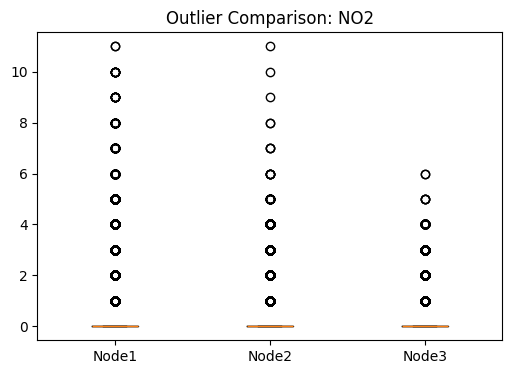

In [59]:
import matplotlib.pyplot as plt

columns_to_check = ['NO2']

for col in columns_to_check:
    plt.figure(figsize=(6,4))
    plt.boxplot([
        node1[col].dropna(),
        node2[col].dropna(),
        node3[col].dropna()
    ], tick_labels=['Node1', 'Node2', 'Node3'])

    plt.title(f'Outlier Comparison: {col}')
    plt.show()

NO2: The presence of so many outliers suggests significant fluctuations or extreme spikes in NO2 concentrations across the entire facility, making it a critical environmental factor to monitor.

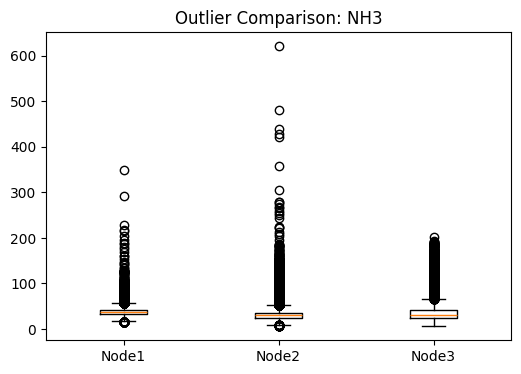

In [61]:
import matplotlib.pyplot as plt

columns_to_check = ['NH3']

for col in columns_to_check:
    plt.figure(figsize=(6,4))
    plt.boxplot([
        node1[col].dropna(),
        node2[col].dropna(),
        node3[col].dropna()
    ], tick_labels=['Node1', 'Node2', 'Node3'])

    plt.title(f'Outlier Comparison: {col}')
    plt.show()

NH3 (Ammonia): Node 1 (Baby Chick Section) has a notable number of outliers, implying that ammonia levels deviate more frequently in this area. Node 2 and Node 3 also have outliers but to a lesser extent.

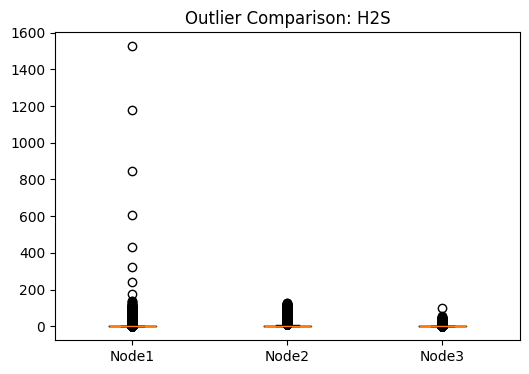

In [60]:
import matplotlib.pyplot as plt

columns_to_check = ['H2S']

for col in columns_to_check:
    plt.figure(figsize=(6,4))
    plt.boxplot([
        node1[col].dropna(),
        node2[col].dropna(),
        node3[col].dropna()
    ], tick_labels=['Node1', 'Node2', 'Node3'])

    plt.title(f'Outlier Comparison: {col}')
    plt.show()

H2S (Hydrogen Sulfide): Node 1 stands out with a very high count of H2S outliers, indicating potential issues with this gas in the baby chicken section.

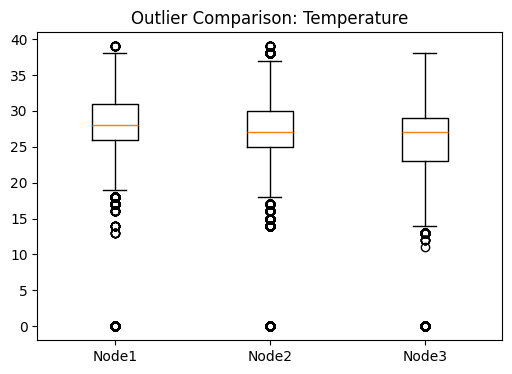

In [62]:
import matplotlib.pyplot as plt

columns_to_check = ['Temperature']

for col in columns_to_check:
    plt.figure(figsize=(6,4))
    plt.boxplot([
        node1[col].dropna(),
        node2[col].dropna(),
        node3[col].dropna()
    ], tick_labels=['Node1', 'Node2', 'Node3'])

    plt.title(f'Outlier Comparison: {col}')
    plt.show()

Temperature: Node 2 shows a significantly higher number of outliers compared to Node 1 and Node 3, indicating more frequent unusual temperature readings in the Main-East Zone.

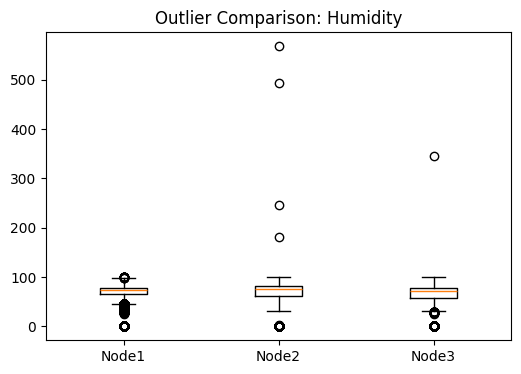

In [63]:
import matplotlib.pyplot as plt

columns_to_check = ['Humidity']

for col in columns_to_check:
    plt.figure(figsize=(6,4))
    plt.boxplot([
        node1[col].dropna(),
        node2[col].dropna(),
        node3[col].dropna()
    ], tick_labels=['Node1', 'Node2', 'Node3'])

    plt.title(f'Outlier Comparison: {col}')
    plt.show()

Humidity: Like Temperature, Node 2 exhibits the most outliers, suggesting fluctuations or extreme humidity levels are more common in the Main-East Zone.

In [ ]:
import matplotlib.pyplot as plt

columns_to_check = ['Noise-Avg', 'Noise-Peak']

for col in columns_to_check:
    plt.figure(figsize=(6,4))
    plt.boxplot([
        node1[col].dropna(),
        node2[col].dropna(),
        node3[col].dropna()
    ], tick_labels=['Node1', 'Node2', 'Node3'])

    plt.title(f'Outlier Comparison: {col}')
    plt.show()

Noise-Avg & Noise-Peak: Node 2 is the only one with a substantial number of average noise outliers, suggesting that this zone experiences more periods of unusually high average noise levels compared to the other two nodes which show very few to no outliers.

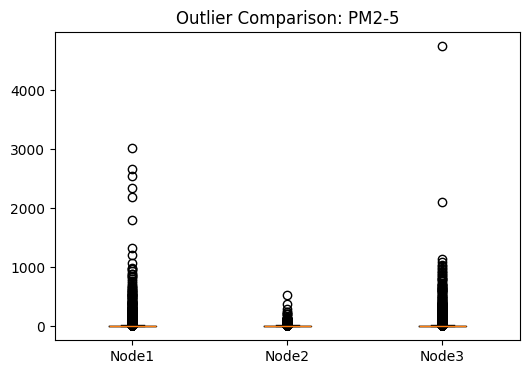

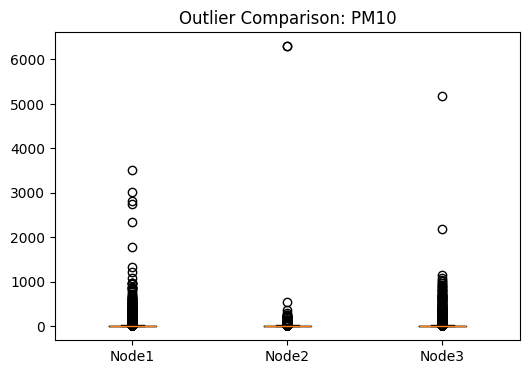

In [16]:
import matplotlib.pyplot as plt

columns_to_check = ['PM2-5', 'PM10']

for col in columns_to_check:
    plt.figure(figsize=(6,4))
    plt.boxplot([
        node1[col].dropna(),
        node2[col].dropna(),
        node3[col].dropna()
    ], tick_labels=['Node1', 'Node2', 'Node3'])

    plt.title(f'Outlier Comparison: {col}')
    plt.show()

PM2-5 & PM10 (Particulate Matter): All three nodes show a considerable number of outliers for both PM2-5 and PM10, with Node 1 and Node 3 generally having more than Node 2.

So, we find high particulate matter readings are a common occurrence across the facility, but particularly in the baby chick and west sections.

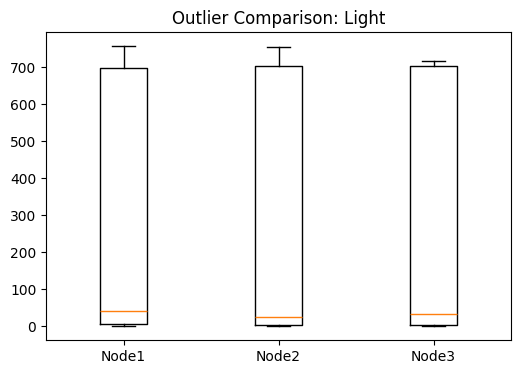

In [64]:
import matplotlib.pyplot as plt

columns_to_check = ['Light']

for col in columns_to_check:
    plt.figure(figsize=(6,4))
    plt.boxplot([
        node1[col].dropna(),
        node2[col].dropna(),
        node3[col].dropna()
    ], tick_labels=['Node1', 'Node2', 'Node3'])

    plt.title(f'Outlier Comparison: {col}')
    plt.show()

Light: No outlier is seen for any node

Visualize the outlier counts for the top 5 features

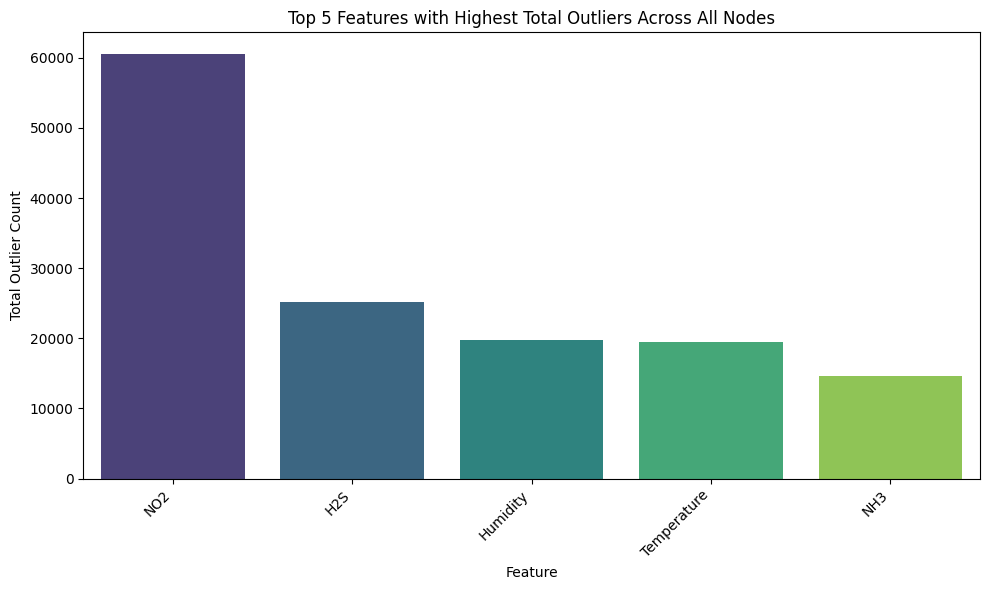

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 5 features with the highest total outliers
top_5_outliers = comparison.sort_values(by='Total_Outliers', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Total_Outliers', data=top_5_outliers, hue='Feature', palette='viridis', legend=False)
plt.title('Top 5 Features with Highest Total Outliers Across All Nodes')
plt.xlabel('Feature')
plt.ylabel('Total Outlier Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The plot / bar chart (sum of node 1+2+3) clearly shows that NO2 has the highest total outlier count, followed by H2S, Humidity, Temperature, and NH3.

Bar chart comparison for the expected outliers across all nodes

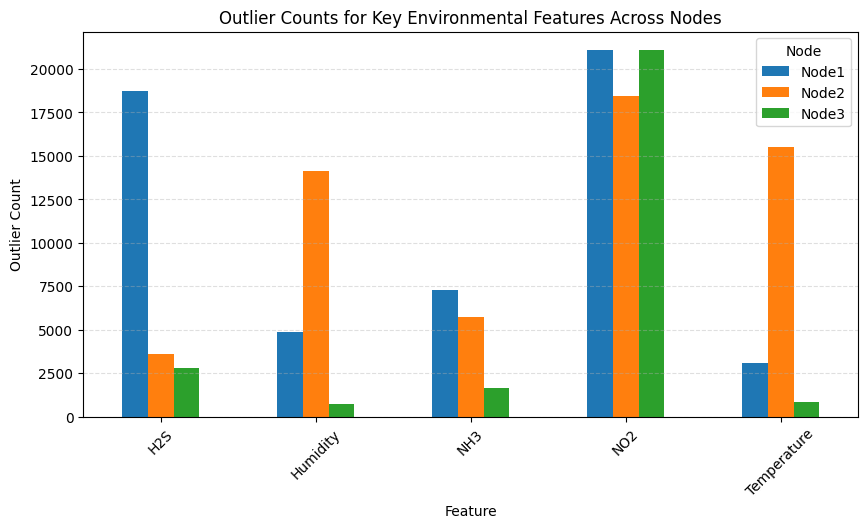

In [51]:
focus_features = ['NO2', 'H2S', 'Humidity', 'Temperature', 'NH3']

focus_data = all_summary[all_summary['Feature'].isin(focus_features)]

pivot_counts = focus_data.pivot(index='Feature', columns='Node', values='Outlier_Count')
pivot_counts.plot(kind='bar', figsize=(10, 5))

plt.title('Outlier Counts for Key Environmental Features Across Nodes')
plt.xlabel('Feature')
plt.ylabel('Outlier Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Node')
plt.show()

Outliers Summary (Heatmap)

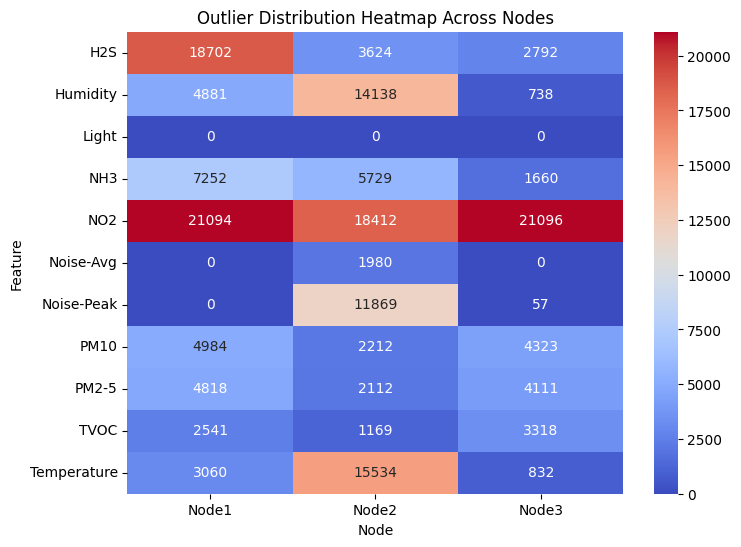

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_counts = all_summary.pivot(index='Feature', columns='Node', values='Outlier_Count')

plt.figure(figsize=(8,6))
sns.heatmap(pivot_counts, annot=True, fmt=".0f", cmap="coolwarm")

plt.title('Outlier Distribution Heatmap Across Nodes')
plt.show()